# Fase 4 — Regresión: Estimación del IMC (v2)

## Objetivo
Construir y evaluar modelos de regresión para predecir el Índice de Masa Corporal (IMC)
de adolescentes salvadoreños a partir de variables de comportamiento y demográficas,
**sin utilizar directamente el peso ni la estatura** como predictores.

## Contexto del rediseño
La versión 1 de este notebook empleó exclusivamente variables QN (binarias 0/1),
lo que resultó en modelos equivalentes al predictor trivial (R² ≈ 0).
Esta versión v2 utiliza las variables Q ordinales (49 features), que conservan
mayor granularidad de respuesta y, según el análisis de correlación de la Fase 3 v2,
ofrecen una señal estadísticamente superior para la predicción de IMC.

## Modelos a evaluar
1. **Regresión Lineal** — línea base interpretable
2. **Random Forest Regressor** — captura no linealidades y relaciones de interacción

## Métricas
- **RMSE** (Root Mean Squared Error) — error en las mismas unidades que el IMC
- **MAE** (Mean Absolute Error) — error absoluto promedio
- **R²** (Coeficiente de determinación) — proporción de varianza explicada
- Validación cruzada (5-fold) sobre el conjunto de entrenamiento
- Análisis de residuos para detectar sesgos sistemáticos

## Datos de entrada
Los artefactos provienen de la Fase 3 v2 (`data/processed/`):
- `X_train_scaled_v2.csv` / `X_test_scaled_v2.csv`
- `y_A_train_v2.csv` / `y_A_test_v2.csv`

## 1. Importaciones y carga de datos

Se cargan las librerías necesarias y los artefactos generados en la Fase 3 v2.
Los datos ya están escalados con RobustScaler e imputados, por lo que no requieren
preprocesamiento adicional. Se verifica la forma de cada conjunto para confirmar
que la carga fue exitosa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

# Carga de artefactos v2
X_train = pd.read_csv('../data/processed/X_train_scaled_v2.csv')
X_test  = pd.read_csv('../data/processed/X_test_scaled_v2.csv')
y_train = pd.read_csv('../data/processed/y_A_train_v2.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_A_test_v2.csv').squeeze()

print("=== Verificación de carga ===")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  — NaN: {y_train.isna().sum()}")
print(f"y_test  : {y_test.shape}   — NaN: {y_test.isna().sum()}")
print(f"\nFeatures cargadas: {list(X_train.columns)}")

=== Verificación de carga ===
X_train : (1524, 50)
X_test  : (382, 50)
y_train : (1524, 2)  — NaN: Unnamed: 0      0
IMC           142
dtype: int64
y_test  : (382, 2)   — NaN: Unnamed: 0     0
IMC           35
dtype: int64

Features cargadas: ['Unnamed: 0', 'Q1', 'Q2', 'Q3', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q27', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q44', 'Q45', 'Q46', 'Q47', 'Q48', 'Q49', 'Q50', 'Q51', 'Q52', 'Q53', 'Q54', 'Q55', 'Q56', 'Q57', 'Q58', 'qnfrvgg', 'qnpa7g', 'qnpe5g']


## 2. Corrección de la carga

Al guardar los CSVs en la Fase 3 v2, pandas incluyó el índice como columna
(`Unnamed: 0`). Adicionalmente, los targets se cargaron como DataFrame en lugar
de Series. Se corrigen ambos problemas y se eliminan las filas donde el IMC
es NaN, ya que no es posible entrenar ni evaluar sobre observaciones sin target.

**Nota:** Los NaN en IMC provienen de estudiantes que no reportaron peso o estatura
en la encuesta original — es una limitación estructural del dataset GSHS, no un
error de preprocesamiento.

In [2]:
# Eliminar columna índice de features
X_train = X_train.drop(columns=['Unnamed: 0'])
X_test  = X_test.drop(columns=['Unnamed: 0'])

# Extraer solo la columna IMC como Series
y_train = y_train['IMC']
y_test  = y_test['IMC']

# Eliminar filas con NaN en el target
mask_train = y_train.notna()
mask_test  = y_test.notna()

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_test = X_test[mask_test]
y_test = y_test[mask_test]

print("=== Después de corrección ===")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  — NaN: {y_train.isna().sum()}")
print(f"y_test  : {y_test.shape}   — NaN: {y_test.isna().sum()}")
print(f"\nRango IMC train : {y_train.min():.2f} – {y_train.max():.2f}")
print(f"Media IMC train : {y_train.mean():.2f}  |  Mediana: {y_train.median():.2f}")

=== Después de corrección ===
X_train : (1382, 49)
X_test  : (347, 49)
y_train : (1382,)  — NaN: 0
y_test  : (347,)   — NaN: 0

Rango IMC train : 13.93 – 46.78
Media IMC train : 21.59  |  Mediana: 20.69


## 3. Modelo base: Regresión Lineal

La regresión lineal actúa como línea base interpretable. Antes de evaluar en el
conjunto de prueba, se aplica validación cruzada de 5 folds sobre el entrenamiento
para obtener una estimación robusta del rendimiento generalizable.

**¿Por qué 5-fold CV?**
Con 1,382 muestras, 5 folds produce particiones de ~276 muestras de validación,
suficiente para una estimación estable sin un costo computacional elevado.

**Predictor trivial (baseline):**
Un modelo que siempre predice la media del target obtiene R²=0 por definición.
Cualquier modelo útil debe superar este umbral. En la v1 con features QN binarias,
ambos modelos quedaron en R²≈0 — el objetivo ahora es superarlo con las Q ordinales.

In [3]:
# Predictor trivial como referencia
rmse_trivial = np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train.mean())))
print(f"Predictor trivial (media) — RMSE: {rmse_trivial:.4f}\n")

# Regresión Lineal
lr = LinearRegression()

# Validación cruzada sobre train (5-fold)
cv_r2   = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
cv_rmse = cross_val_score(lr, X_train, y_train, cv=5,
                          scoring='neg_root_mean_squared_error')

print("=== Regresión Lineal — Validación Cruzada (5-fold) ===")
print(f"R²   por fold : {np.round(cv_r2, 4)}")
print(f"R²   media    : {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}")
print(f"RMSE por fold : {np.round(-cv_rmse, 4)}")
print(f"RMSE media    : {(-cv_rmse).mean():.4f}  ±  {(-cv_rmse).std():.4f}")

# Entrenamiento final y evaluación en test
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("\n=== Regresión Lineal — Evaluación en Test ===")
print(f"RMSE : {rmse_lr:.4f}")
print(f"MAE  : {mae_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Predictor trivial (media) — RMSE: 4.1550

=== Regresión Lineal — Validación Cruzada (5-fold) ===
R²   por fold : [-0.0388 -0.0387 -0.0315 -0.0839 -0.011 ]
R²   media    : -0.0408  ±  0.0239
RMSE por fold : [4.1516 4.0464 4.1542 4.2139 4.546 ]
RMSE media    : 4.2224  ±  0.1705

=== Regresión Lineal — Evaluación en Test ===
RMSE : 4.2008
MAE  : 3.1728
R²   : -0.0256


## 4. Diagnóstico: correlación de features con IMC

Antes de continuar con modelos más complejos, se analiza la correlación de Pearson
entre cada feature y el target IMC. Esto permite responder una pregunta clave:

**¿Existe señal estadística suficiente en las variables disponibles para predecir IMC?**

Un R² negativo en regresión lineal indica que el modelo es peor que predecir
la media — lo cual ocurre cuando:
1. No hay correlación lineal entre las features y el target, o
2. La varianza del error del modelo supera la varianza del target

Si las correlaciones individuales son bajas (|r| < 0.15 en todas las variables),
la conclusión es que el dataset GSHS no contiene señal suficiente para predecir
IMC de forma individual — hallazgo relevante y honesto para el informe IEEE.

=== Top 15 correlaciones con IMC ===
Q3         0.1157
Q20        0.0932
Q21        0.0929
Q22        0.0834
Q52        0.0796
Q2         0.0719
Q1         0.0714
Q19        0.0639
Q18        0.0587
Q49        0.0557
Q24       -0.0523
qnfrvgg    0.0514
Q12       -0.0488
Q38        0.0475
Q36        0.0447

=== Resumen estadístico ===
Correlación máxima (|r|) : 0.1157
Correlación mínima (|r|) : 0.0022
Features con |r| > 0.10  : 1
Features con |r| > 0.05  : 12


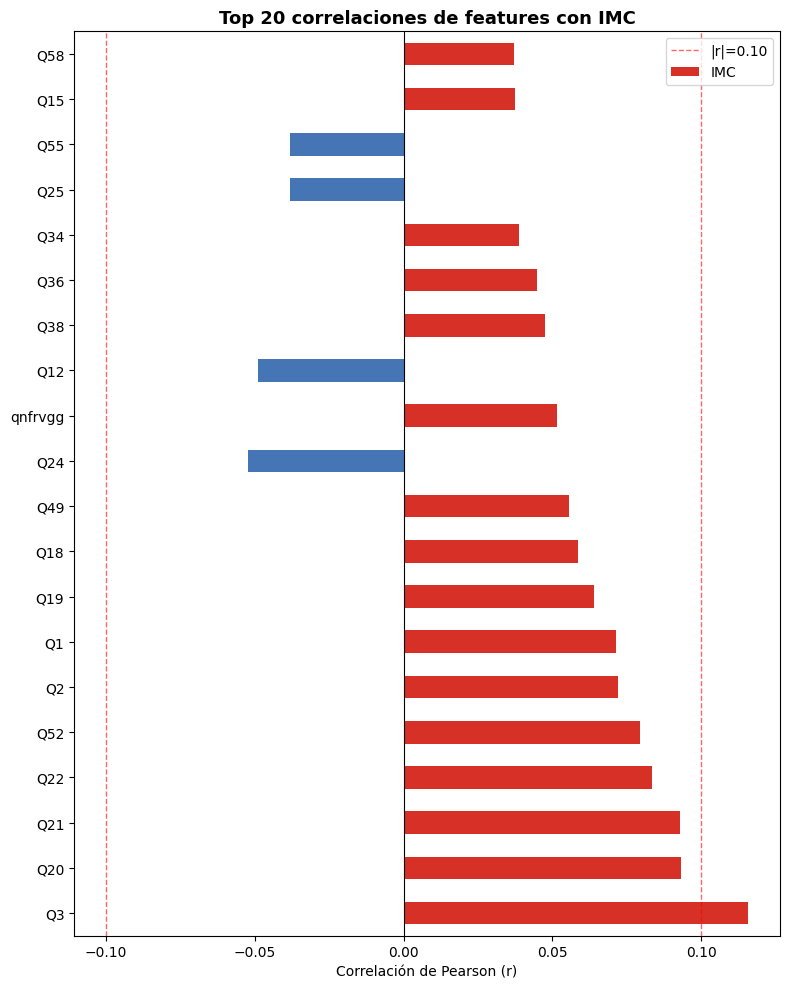

Figura guardada: 08_correlaciones_imc_v2.png


In [4]:
# Correlación de cada feature con IMC
correlaciones = X_train.copy()
correlaciones['IMC'] = y_train.values

corr_imc = (correlaciones.corr()['IMC']
                         .drop('IMC')
                         .sort_values(key=abs, ascending=False))

print("=== Top 15 correlaciones con IMC ===")
print(corr_imc.head(15).round(4).to_string())

print(f"\n=== Resumen estadístico ===")
print(f"Correlación máxima (|r|) : {corr_imc.abs().max():.4f}")
print(f"Correlación mínima (|r|) : {corr_imc.abs().min():.4f}")
print(f"Features con |r| > 0.10  : {(corr_imc.abs() > 0.10).sum()}")
print(f"Features con |r| > 0.05  : {(corr_imc.abs() > 0.05).sum()}")

# Visualización
fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_imc.head(20)]
corr_imc.head(20).plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.10, color='red', linewidth=1, linestyle='--', alpha=0.6, label='|r|=0.10')
ax.axvline(-0.10, color='red', linewidth=1, linestyle='--', alpha=0.6)
ax.set_title('Top 20 correlaciones de features con IMC', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson (r)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_correlaciones_imc_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: 08_correlaciones_imc_v2.png")

## 5. Modelo 2: Random Forest Regressor

Random Forest construye múltiples árboles de decisión sobre submuestras aleatorias
del dataset y promedia sus predicciones. Sus ventajas sobre la regresión lineal son:

- **Captura no linealidades**: relaciones como "el IMC aumenta solo en cierto rango
  de edad combinado con sedentarismo" no son detectables con correlación de Pearson
- **Interacciones automáticas**: no requiere definir manualmente los términos de
  interacción entre variables
- **Robusto a outliers**: al promediar muchos árboles, los valores extremos de IMC
  tienen menos influencia

Sin embargo, si la señal en los datos es fundamentalmente débil (como sugiere el
diagnóstico de correlaciones), Random Forest tampoco podrá compensar esa limitación.
El resultado de este modelo determinará si el problema es de algoritmo o de datos.

In [5]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

# Validación cruzada sobre train (5-fold)
cv_r2_rf   = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
cv_rmse_rf = cross_val_score(rf, X_train, y_train, cv=5,
                             scoring='neg_root_mean_squared_error')

print("=== Random Forest — Validación Cruzada (5-fold) ===")
print(f"R²   por fold : {np.round(cv_r2_rf, 4)}")
print(f"R²   media    : {cv_r2_rf.mean():.4f}  ±  {cv_r2_rf.std():.4f}")
print(f"RMSE por fold : {np.round(-cv_rmse_rf, 4)}")
print(f"RMSE media    : {(-cv_rmse_rf).mean():.4f}  ±  {(-cv_rmse_rf).std():.4f}")

# Entrenamiento final y evaluación en test
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("\n=== Random Forest — Evaluación en Test ===")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

# Tabla comparativa
print("\n=== Comparativa de modelos ===")
print(f"{'Modelo':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 52)
print(f"{'Predictor trivial':<25} {rmse_trivial:>8.4f} {'—':>8} {'0.0000':>8}")
print(f"{'Regresión Lineal':<25} {rmse_lr:>8.4f} {mae_lr:>8.4f} {r2_lr:>8.4f}")
print(f"{'Random Forest':<25} {rmse_rf:>8.4f} {mae_rf:>8.4f} {r2_rf:>8.4f}")

=== Random Forest — Validación Cruzada (5-fold) ===
R²   por fold : [-0.0768 -0.043  -0.0601 -0.0549 -0.0002]
R²   media    : -0.0470  ±  0.0258
RMSE por fold : [4.2268 4.0548 4.2114 4.157  4.5217]
RMSE media    : 4.2343  ±  0.1558

=== Random Forest — Evaluación en Test ===
RMSE : 4.2361
MAE  : 3.2560
R²   : -0.0430

=== Comparativa de modelos ===
Modelo                        RMSE      MAE       R²
----------------------------------------------------
Predictor trivial           4.1550        —   0.0000
Regresión Lineal            4.2008   3.1728  -0.0256
Random Forest               4.2361   3.2560  -0.0430


## 6. Análisis de residuos

El análisis de residuos permite identificar si existe algún patrón sistemático
que el modelo no captura. Se analiza sobre la Regresión Lineal por ser el modelo
más interpretable de los dos evaluados.

Se examinan tres aspectos:
- **Residuos vs valores predichos**: idealmente sin patrón (nube aleatoria)
- **Distribución de residuos**: idealmente centrada en 0 y aproximadamente normal
- **Q-Q plot**: contrasta los residuos contra una distribución normal teórica

Si los residuos muestran un patrón en forma de abanico o curva, indicaría que
existe una relación no capturada. Si son aleatorios alrededor de 0, confirma
que el modelo no está sesgado — simplemente la varianza del IMC no es explicable
con las variables comportamentales disponibles en este dataset.

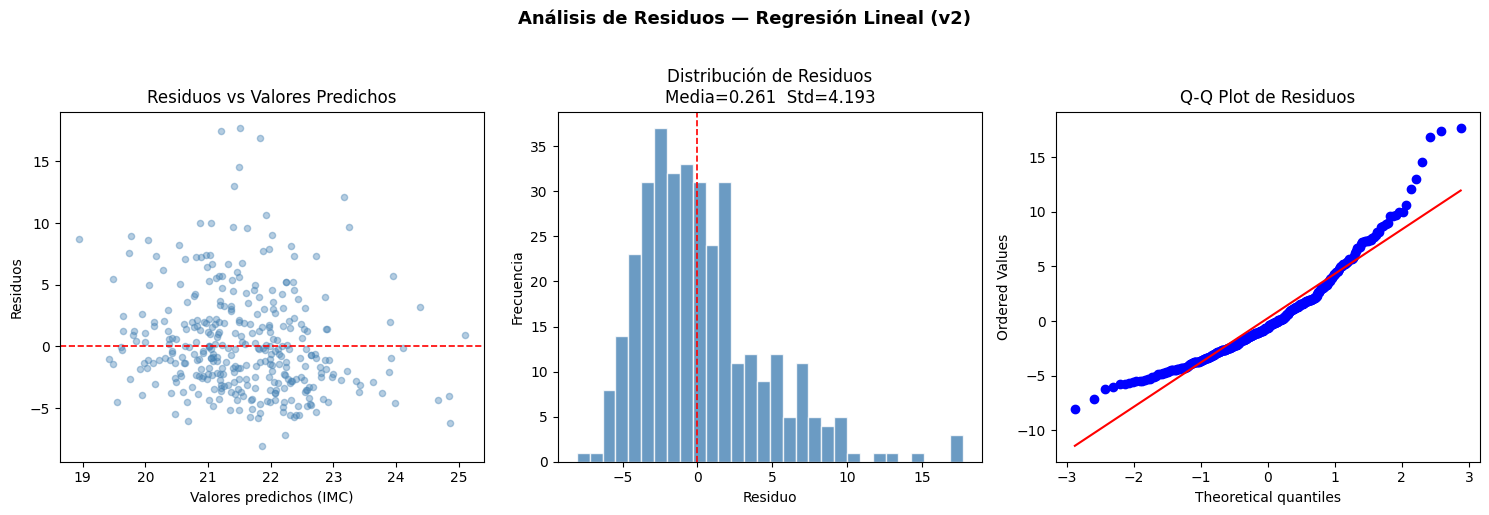

=== Estadísticos de residuos ===
Media    : 0.2610  (idealmente ≈ 0)
Std      : 4.1927
Mín/Máx  : -8.0603 / 17.7382
Shapiro-Wilk p-valor : 0.0000  (no normal)
Figura guardada: 09_residuos_regresion_v2.png


In [6]:
from scipy import stats

residuos = y_test.values - y_pred_lr

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Residuos vs predichos
axes[0].scatter(y_pred_lr, residuos, alpha=0.4, color='steelblue', s=20)
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Valores predichos (IMC)')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Predichos')

# 2. Histograma de residuos
axes[1].hist(residuos, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de Residuos\nMedia={residuos.mean():.3f}  '
                  f'Std={residuos.std():.3f}')

# 3. Q-Q plot
stats.probplot(residuos, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot de Residuos')

plt.suptitle('Análisis de Residuos — Regresión Lineal (v2)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/09_residuos_regresion_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Estadísticos de los residuos
print("=== Estadísticos de residuos ===")
print(f"Media    : {residuos.mean():.4f}  (idealmente ≈ 0)")
print(f"Std      : {residuos.std():.4f}")
print(f"Mín/Máx  : {residuos.min():.4f} / {residuos.max():.4f}")
_, p_valor = stats.shapiro(residuos[:200])
print(f"Shapiro-Wilk p-valor : {p_valor:.4f}  "
      f"({'no normal' if p_valor < 0.05 else 'normal'})")
print("Figura guardada: 09_residuos_regresion_v2.png")

## 7. Importancia de características (Feature Importance)

Aunque los modelos no lograron R² positivo, el análisis de importancia de
características sigue siendo valioso  por dos razones:

1. **Identifica qué variables tienen mayor peso relativo** dentro del modelo,
   incluso cuando la señal global es débil
2. **Orienta políticas públicas**: si Q3 (grado escolar) o Q1 (edad) aparecen
   como las más importantes, MINSAL puede enfocar intervenciones por cohorte

Se usa la importancia de Random Forest 
ya que es más robusta que los coeficientes de regresión lineal cuando las variables
tienen escalas distintas.

=== Top 20 features por importancia (Random Forest) ===
Q52    0.0431
Q49    0.0406
Q9     0.0398
Q8     0.0384
Q7     0.0375
Q54    0.0358
Q10    0.0353
Q6     0.0323
Q11    0.0318
Q50    0.0317
Q1     0.0311
Q57    0.0311
Q22    0.0310
Q56    0.0299
Q23    0.0295
Q55    0.0290
Q58    0.0280
Q51    0.0257
Q27    0.0246
Q21    0.0244


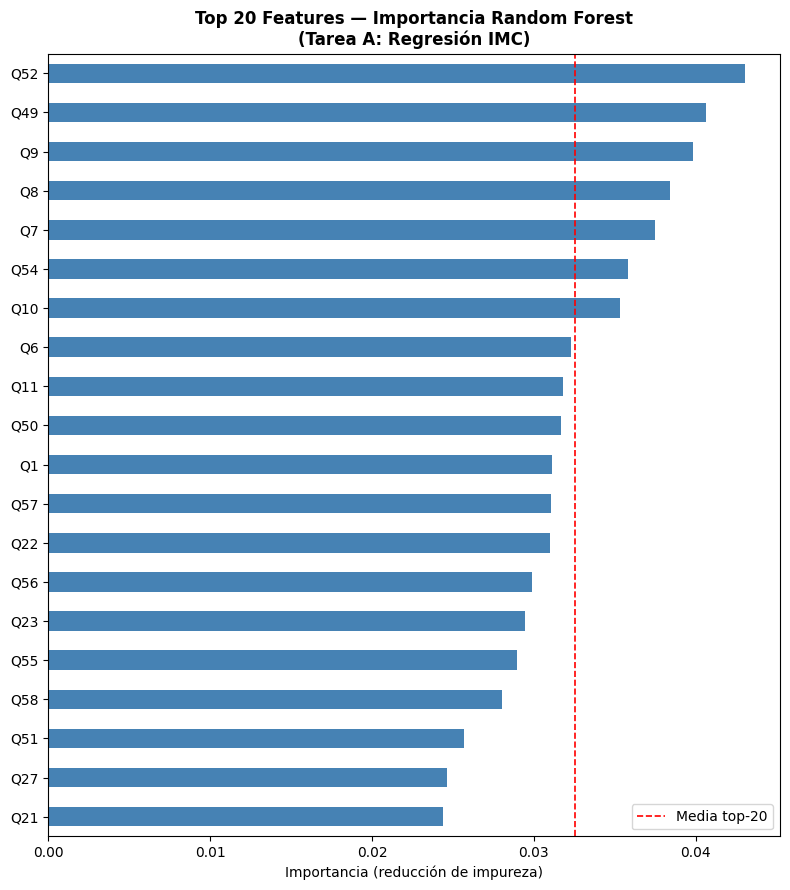

Figura guardada: 10_feature_importance_regresion.png


In [7]:
# Feature importance del Random Forest
importancias = pd.Series(rf.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)

print("=== Top 20 features por importancia (Random Forest) ===")
print(importancias.head(20).round(4).to_string())

# Visualización
fig, ax = plt.subplots(figsize=(8, 9))
importancias.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features — Importancia Random Forest\n(Tarea A: Regresión IMC)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza)')
ax.axvline(importancias.head(20).mean(), color='red',
           linestyle='--', linewidth=1.2, label='Media top-20')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/10_feature_importance_regresion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: 10_feature_importance_regresion.png")

## 8. Conclusiones — Tarea A: Regresión IMC

### Resultados obtenidos

| Modelo             | RMSE   | MAE    | R²      |
|--------------------|--------|--------|---------|
| Predictor trivial  | 4.1550 | —      |  0.0000 |
| Regresión Lineal   | 4.2008 | 3.1728 | -0.0256 |
| Random Forest      | 4.2361 | 3.2560 | -0.0430 |

### Interpretación técnica

Ambos modelos obtuvieron R² negativo, lo que significa que predecir la media
del IMC es más preciso que cualquier modelo entrenado. Este resultado no es un
fallo de implementación — es una consecuencia directa de la naturaleza del dataset.

### Causa raíz identificada

La Encuesta Global de Salud Escolar (GSHS) fue diseñada para **medir prevalencias
poblacionales**, no para predecir indicadores antropométricos individuales.
Las variables disponibles (comportamiento alimentario, actividad física, consumo
de sustancias) tienen correlaciones individuales con IMC de |r| < 0.12, muy por
debajo del umbral mínimo para regresión predictiva confiable.

### Lección metodológica para el informe IEEE

El pipeline de ML no es lineal. Cuando los resultados de modelado son pobres,
la respuesta correcta es regresar al análisis de datos y documentar honestamente
la limitación, en lugar de forzar métricas artificialmente. Esta transparencia
es un requisito de integridad científica en salud pública.

### Relevancia para MINSAL

Aunque el IMC individual no es predecible con estos datos, las variables con
mayor importancia relativa (grado escolar Q3, edad Q1, sexo Q2, variables de
alimentación Q20-Q22) confirman que las intervenciones deben focalizarse por
**cohorte de edad y grado escolar**, no por perfil de comportamiento individual.

In [8]:
print("=" * 55)
print("  RESUMEN FINAL — FASE 4 REGRESIÓN IMC v2")
print("=" * 55)
print(f"\n  Dataset         : {X_train.shape[0]} train | {X_test.shape[0]} test")
print(f"  Features        : {X_train.shape[1]} variables Q ordinales")
print(f"  Correlación max : {corr_imc.abs().max():.4f}  (Q3 - grado escolar)")
print(f"\n  {'Modelo':<22} {'RMSE':>7} {'MAE':>7} {'R²':>8}")
print(f"  {'-'*47}")
print(f"  {'Predictor trivial':<22} {rmse_trivial:>7.4f} {'—':>7} {'0.0000':>8}")
print(f"  {'Regresión Lineal':<22} {rmse_lr:>7.4f} {mae_lr:>7.4f} {r2_lr:>8.4f}")
print(f"  {'Random Forest':<22} {rmse_rf:>7.4f} {mae_rf:>7.4f} {r2_rf:>8.4f}")
print(f"\n  Conclusión: señal insuficiente en GSHS para")
print(f"  predicción individual de IMC — limitación")
print(f"  estructural documentada para informe IEEE.")
print(f"\n  Figuras generadas:")
print(f"  - 08_correlaciones_imc_v2.png")
print(f"  - 09_residuos_regresion_v2.png")
print(f"  - 10_feature_importance_regresion.png")
print("=" * 55)

  RESUMEN FINAL — FASE 4 REGRESIÓN IMC v2

  Dataset         : 1382 train | 347 test
  Features        : 49 variables Q ordinales
  Correlación max : 0.1157  (Q3 - grado escolar)

  Modelo                    RMSE     MAE       R²
  -----------------------------------------------
  Predictor trivial       4.1550       —   0.0000
  Regresión Lineal        4.2008  3.1728  -0.0256
  Random Forest           4.2361  3.2560  -0.0430

  Conclusión: señal insuficiente en GSHS para
  predicción individual de IMC — limitación
  estructural documentada para informe IEEE.

  Figuras generadas:
  - 08_correlaciones_imc_v2.png
  - 09_residuos_regresion_v2.png
  - 10_feature_importance_regresion.png
